In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Time Series Forecasting for Stock Index Prediction

## Data Preparation

We will prepare the data by converting the 'time' column to datetime objects and setting it as the index. Then, we will identify the target variable ('close_index') and create two sets of features: one with only 'open_xxx' columns and another with all available features.

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/LAB/DATA/DATA_RESEARCH/stock/vn30_open_index_gpt_score_raw.csv")
df.head()

,time,open_ACB,open_BCM,open_BID,open_CTG,open_DGC,open_FPT,open_GAS,open_GVR,open_HDB,...,GPT_94,GPT_95,GPT_96,GPT_97,GPT_98,GPT_99,GPT_100,GPT_101,GPT_102,GPT_103
0,2025-07-01,21.30,64.6,35.95,28.60,97.92,102.42,63.54,30.22,16.85,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-07-02,21.30,64.5,36.20,28.70,96.67,101.99,62.50,30.76,17.08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-07-03,21.35,66.0,36.10,28.70,96.38,101.99,62.97,30.02,17.20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-07-04,21.45,66.4,36.05,29.29,98.59,101.99,62.50,29.18,17.47,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-07-07,22.05,66.4,36.25,29.49,98.30,106.12,62.78,29.28,17.47,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data Preprocessing
We will convert the time column, set it as the index, and handle missing values. For the GPT features, we'll fill missing values with 0.

In [ ]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import xgboost as xgb
import lightgbm as lgb

# Prepare dataframe
df['time'] = pd.to_datetime(df['time'])
df = df.set_index('time').sort_index()

# Handle missing values for GPT columns
gpt_cols = [c for c in df.columns if 'GPT_' in c]
df[gpt_cols] = df[gpt_cols].fillna(0)

# Define feature sets
open_features = [c for c in df.columns if c.startswith('open_')]
all_features = [c for c in df.columns if c.startswith('open_') or c.startswith('GPT_')]

# Ensure target exists - if 'close_index' is missing, this will show an error
target = 'close_index'
if target not in df.columns:
    print(f"Warning: '{target}' not found. Please ensure you have loaded the target variable.")
else:
    print(f"Target '{target}' identified. Feature sets: Open ({len(open_features)}), All ({len(all_features)})")

Target 'close_index' identified. Feature sets: Open (31), All (134)


### Model Training and Evaluation
We define a function to run the GridSearchCV for different models and compare their metrics.

In [ ]:
def evaluate_models(X, y, split_ratio=0.8):
    limit = int(len(X) * split_ratio)
    X_train, X_test = X.iloc[:limit], X.iloc[limit:]
    y_train, y_test = y.iloc[:limit], y.iloc[limit:]
    tscv = TimeSeriesSplit(n_splits=5)
    results = []

    models = {
        'LinearRegression': (LinearRegression(), {}),
        'Ridge': (Ridge(), {'model__alpha': [0.1, 1.0, 10.0]}),
        'XGBoost': (xgb.XGBRegressor(objective='reg:squarederror'), {'model__n_estimators': [50, 100], 'model__max_depth': [3, 5]}),
        'LightGBM': (lgb.LGBMRegressor(verbosity=-1), {'model__n_estimators': [50, 100], 'model__learning_rate': [0.05, 0.1]})
    }

    for name, (model, params) in models.items():
        pipeline = Pipeline([('scaler', StandardScaler()), ('model', model)])
        grid = GridSearchCV(pipeline, params, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)

        results.append({'Model': name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape})

    return pd.DataFrame(results)

if target in df.columns:
    y = df[target].dropna()
    X_open = df.loc[y.index, open_features]
    X_all = df.loc[y.index, all_features]

    print("Evaluating 'Open Only' features...")
    res_open = evaluate_models(X_open, y)
    res_open['Feature_Set'] = 'Open_Only'

    print("Evaluating 'All' features...")
    res_all = evaluate_models(X_all, y)
    res_all['Feature_Set'] = 'All_Features'

    final_comparison = pd.concat([res_open, res_all])
    display(final_comparison.sort_values(by='RMSE'))

Evaluating 'Open Only' features...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Evaluating 'All' features...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Model,MSE,RMSE,MAE,MAPE,Feature_Set
0,LinearRegression,5.766403e-26,2.401334e-13,1.836480e-13,1.156137e-16,All_Features
0,LinearRegression,5.806172e-25,7.619824e-13,7.520822e-13,4.736410e-16,Open_Only
1,Ridge,3.248601e-01,5.699650e-01,4.892882e-01,3.066521e-04,Open_Only
1,Ridge,5.996686e+00,2.448813e+00,2.061633e+00,1.308699e-03,All_Features
2,XGBoost,2.128724e+04,1.459015e+02,1.297624e+02,8.310851e-02,Open_Only
2,XGBoost,2.159617e+04,1.469563e+02,1.310173e+02,8.389167e-02,All_Features
3,LightGBM,3.054974e+04,1.747848e+02,1.606480e+02,1.025207e-01,Open_Only
3,LightGBM,3.279025e+04,1.810808e+02,1.675594e+02,1.068430e-01,All_Features


### Cải tiến: Thêm biến trễ (Lag Features)
Để tránh rò rỉ dữ liệu và làm cho bài toán thực tế hơn, chúng ta sẽ dịch chuyển các đặc trưng lùi lại 1 phiên (Lag 1) để dự báo giá đóng cửa phiên tiếp theo.

In [ ]:
def evaluate_improved_models(df, feature_cols, target_col, split_ratio=0.8):
    # Tạo biến trễ cho tất cả features (dùng dữ liệu hôm qua dự báo hôm nay)
    X = df[feature_cols].shift(1)
    y = df[target_col]

    # Loại bỏ dòng đầu tiên vì bị NaN do shift
    valid_idx = X.dropna().index.intersection(y.dropna().index)
    X = X.loc[valid_idx]
    y = y.loc[valid_idx]

    limit = int(len(X) * split_ratio)
    X_train, X_test = X.iloc[:limit], X.iloc[limit:]
    y_train, y_test = y.iloc[:limit], y.iloc[limit:]

    tscv = TimeSeriesSplit(n_splits=5)
    results = []

    models = {
        'Ridge': (Ridge(), {'model__alpha': [0.01, 0.1, 1, 10]}),
        'XGBoost': (xgb.XGBRegressor(objective='reg:squarederror'), {'model__n_estimators': [50, 100], 'model__learning_rate': [0.01, 0.1]}),
        'LinearRegression': (LinearRegression(), {})
    }

    for name, (model, params) in models.items():
        pipeline = Pipeline([('scaler', StandardScaler()), ('model', model)])
        grid = GridSearchCV(pipeline, params, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
        grid.fit(X_train, y_train)

        y_pred = grid.best_estimator_.predict(X_test)
        results.append({
            'Model': name,
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'MAE': mean_absolute_error(y_test, y_pred),
            'MAPE': mean_absolute_percentage_error(y_test, y_pred)
        })

    return pd.DataFrame(results)

# Chạy đánh giá với Lag
print("Evaluating with Lag-1 Features (All Features)...")
res_lag = evaluate_improved_models(df, all_features, target)
display(res_lag.sort_values('RMSE'))

Evaluating with Lag-1 Features (All Features)...


,Model,RMSE,MAE,MAPE
0,Ridge,61.612824,53.198801,0.034015
1,XGBoost,183.607446,169.281739,0.107946
2,LinearRegression,221.396950,198.585799,0.126886


### Cải tiến: Feature Importance & Rolling Windows
Chúng ta sẽ tạo thêm các biến trung bình trượt 5 phiên cho các đặc trưng quan trọng và quan sát tầm quan trọng của các biến trong mô hình XGBoost.

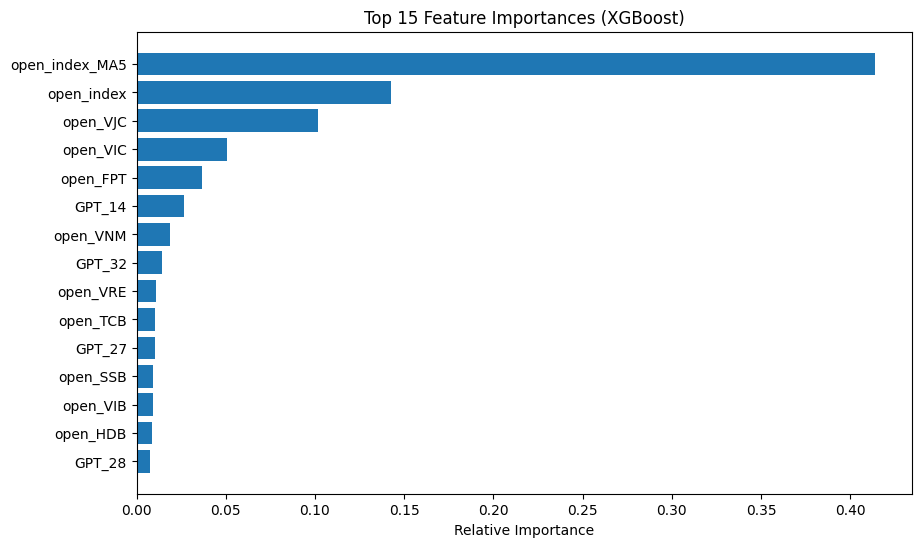

New RMSE with Rolling Features: 89.1552


In [ ]:
import matplotlib.pyplot as plt

split_ratio = 0.8
# 1. Tạo Rolling Features cho 'open_index' và một số GPT tiêu biểu (hoặc toàn bộ)
# Ở đây ta tạo cho các đặc trưng chính để tránh làm bùng nổ số lượng cột quá lớn
df_rolling = df.copy()
for col in ['open_index']:
    df_rolling[f'{col}_MA5'] = df_rolling[col].rolling(window=5).mean()

# Cập nhật danh sách feature bao gồm các cột MA
features_with_rolling = all_features + [f'open_index_MA5']

# Chuẩn bị dữ liệu với Lag-1
X = df_rolling[features_with_rolling].shift(1)
y = df_rolling[target]

valid_idx = X.dropna().index.intersection(y.dropna().index)
X_final = X.loc[valid_idx]
y_final = y.loc[valid_idx]

limit = int(len(X) * split_ratio)
X_train, X_test = X_final.iloc[:limit], X_final.iloc[limit:]
y_train, y_test = y_final.iloc[:limit], y_final.iloc[limit:]

# 2. Huấn luyện mô hình XGBoost tốt nhất
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {'n_estimators': [100], 'learning_rate': [0.1], 'max_depth': [3, 5]}

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
grid_search = GridSearchCV(xgb_model, param_grid, cv=tscv, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_

# 3. Trích xuất và trực quan hóa Feature Importance
importances = best_xgb.feature_importances_
indices = np.argsort(importances)[-15:]  # Top 15 đặc trưng

plt.figure(figsize=(10, 6))
plt.title('Top 15 Feature Importances (XGBoost)')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X_final.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

# In kết quả đánh giá mới
y_pred = best_xgb.predict(X_test)
print(f"New RMSE with Rolling Features: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

## Xây dựng mô hình BiLSTM
Trong phần này, chúng ta sẽ chuyển đổi dữ liệu chuỗi thời gian thành các tập mẫu có độ dài cố định (window) và huấn luyện mô hình mạng neural sâu.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from sklearn.preprocessing import MinMaxScaler

# 1. Chuẩn bị dữ liệu cho Deep Learning
def create_sequences(data, target, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(target[i + window_size])
    return np.array(X), np.array(y)

# Chuẩn hóa dữ liệu
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Sử dụng tập đặc trưng tốt nhất từ các bước trước
X_scaled = scaler_X.fit_transform(X_final)
y_scaled = scaler_y.fit_transform(y_final.values.reshape(-1, 1))

WINDOW_SIZE = 10
X_seq, y_seq = create_sequences(X_scaled, y_scaled, WINDOW_SIZE)

# Chia tập Train/Test theo thời gian
limit = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:limit], X_seq[limit:]
y_train, y_test = y_seq[:limit], y_seq[limit:]

print(f"Kích thước tập huấn luyện: {X_train.shape}")

Kích thước tập huấn luyện: (92, 10, 135)


In [ ]:
# 2. Định nghĩa kiến trúc BiLSTM
model = Sequential([
    Bidirectional(LSTM(128, return_sequences=True), input_shape=(WINDOW_SIZE, X_train.shape[2])),
    Dropout(0.2),
    Bidirectional(LSTM(64)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# 3. Huấn luyện
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 10, 256)        │       270,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 436,769 (1.67 MB)

 Trainable params: 436,769 (1.67 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 296ms/step - loss: 0.0971 - val_loss: 0.1723
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0334 - val_loss: 0.1201
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0203 - val_loss: 0.2221
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0249 - val_loss: 0.0739
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0131 - val_loss: 0.1418
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0121 - val_loss: 0.0595
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0110 - val_loss: 0.0941
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0132 - val_loss: 0.0449
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0118 - val_loss: 0.0592
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0115 - val_loss: 0.0790
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0102 - val_loss: 0.0586
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0091 - val_loss: 0.0412


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 605ms/step

BiLSTM Test RMSE: 94.2354


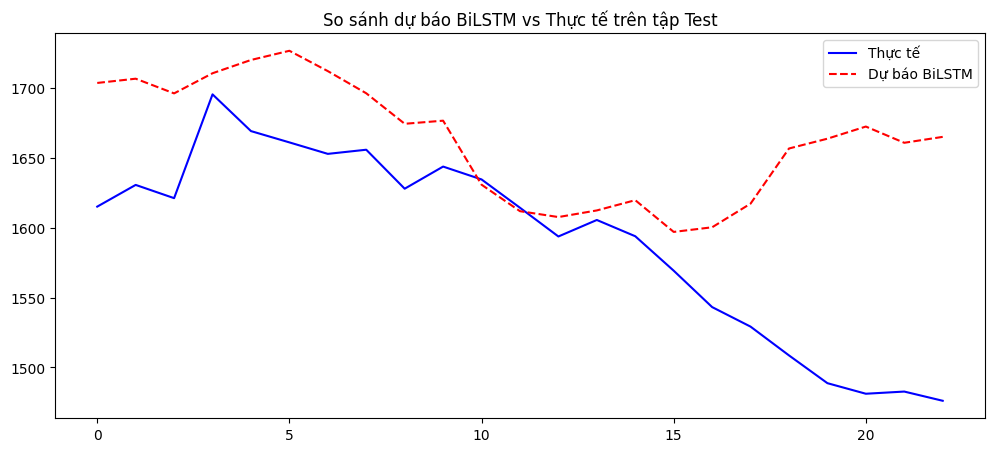

In [ ]:
# 4. Dự báo và đánh giá
y_pred_scaled = model.predict(X_test)
y_pred_inv = scaler_y.inverse_transform(y_pred_scaled)
y_test_inv = scaler_y.inverse_transform(y_test)

rmse_bilstm = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
print(f"\nBiLSTM Test RMSE: {rmse_bilstm:.4f}")

# Trực quan hóa kết quả dự báo trên tập test
plt.figure(figsize=(12, 5))
plt.plot(y_test_inv, label='Thực tế', color='blue')
plt.plot(y_pred_inv, label='Dự báo BiLSTM', color='red', linestyle='--')
plt.title('So sánh dự báo BiLSTM vs Thực tế trên tập Test')
plt.legend()
plt.show()

### So sánh XGBoost với Feature Engineering: Open vs All (GPT)
Chúng ta sẽ tạo các biến trễ (Lag-1) và trung bình trượt (MA5) cho cả hai hướng để so sánh hiệu suất dự báo thực tế.

In [ ]:
def prepare_engineered_data(df, base_features, target_col):
    df_eng = df.copy()
    all_eng_features = []

    for col in base_features:
        # Tạo Lag-1 (Dữ liệu hôm qua)
        df_eng[f'{col}_lag1'] = df_eng[col].shift(1)
        all_eng_features.append(f'{col}_lag1')

        # Tạo MA5 cho các cột quan trọng (ví dụ index và chính nó)
        if col == 'open_index' or col.startswith('open_'):
            df_eng[f'{col}_ma5'] = df_eng[col].shift(1).rolling(window=5).mean()
            all_eng_features.append(f'{col}_ma5')

    X = df_eng[all_eng_features]
    y = df_eng[target_col]

    valid_idx = X.dropna().index.intersection(y.dropna().index)
    return X.loc[valid_idx], y.loc[valid_idx]

def train_xgb_optimized(X, y, split_ratio = 0.8):
    # Chia tập Train/Test theo thời gian
    limit = int(len(X) * split_ratio)
    X_train, X_test = X[:limit], X[limit:]
    y_train, y_test = y[:limit], y[limit:]

    tscv = TimeSeriesSplit(n_splits=5)
    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5],
        'subsample': [0.8]
    }
    grid = GridSearchCV(xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
                        param_grid, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    return {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MAPE': mean_absolute_percentage_error(y_test, y_pred)
    }

# Thực hiện cho 2 hướng
# Hướng 1: Chỉ dùng Open features
X_open_eng, y_open_eng = prepare_engineered_data(df, open_features, target)
res_open_opt = train_xgb_optimized(X_open_eng, y_open_eng)
res_open_opt['Feature_Set'] = 'Open_Only_Engineered'

# Hướng 2: Dùng All features (bao gồm GPT)
X_all_eng, y_all_eng = prepare_engineered_data(df, all_features, target)
res_all_opt = train_xgb_optimized(X_all_eng, y_all_eng)
res_all_opt['Feature_Set'] = 'All_Features_sentiment_Engineered'

# Lập bảng so sánh
comparison_df = pd.DataFrame([res_open_opt, res_all_opt])
display(comparison_df[['Feature_Set', 'RMSE', 'MAE', 'MAPE']])

/tmp/ipykernel_3433/3642391758.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eng[f'{col}_lag1'] = df_eng[col].shift(1)
/tmp/ipykernel_3433/3642391758.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eng[f'{col}_lag1'] = df_eng[col].shift(1)
/tmp/ipykernel_3433/3642391758.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented f

,Feature_Set,RMSE,MAE,MAPE
0,Open_Only_Engineered,188.208882,169.011229,0.108235
1,All_Features_sentiment_Engineered,198.603090,179.173563,0.114692


### Trực quan hóa Feature Importance
Dưới đây là biểu đồ hiển thị các đặc trưng quan trọng nhất từ mô hình XGBoost sử dụng đầy đủ các biến đã được Feature Engineering.

/tmp/ipykernel_3433/998736400.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


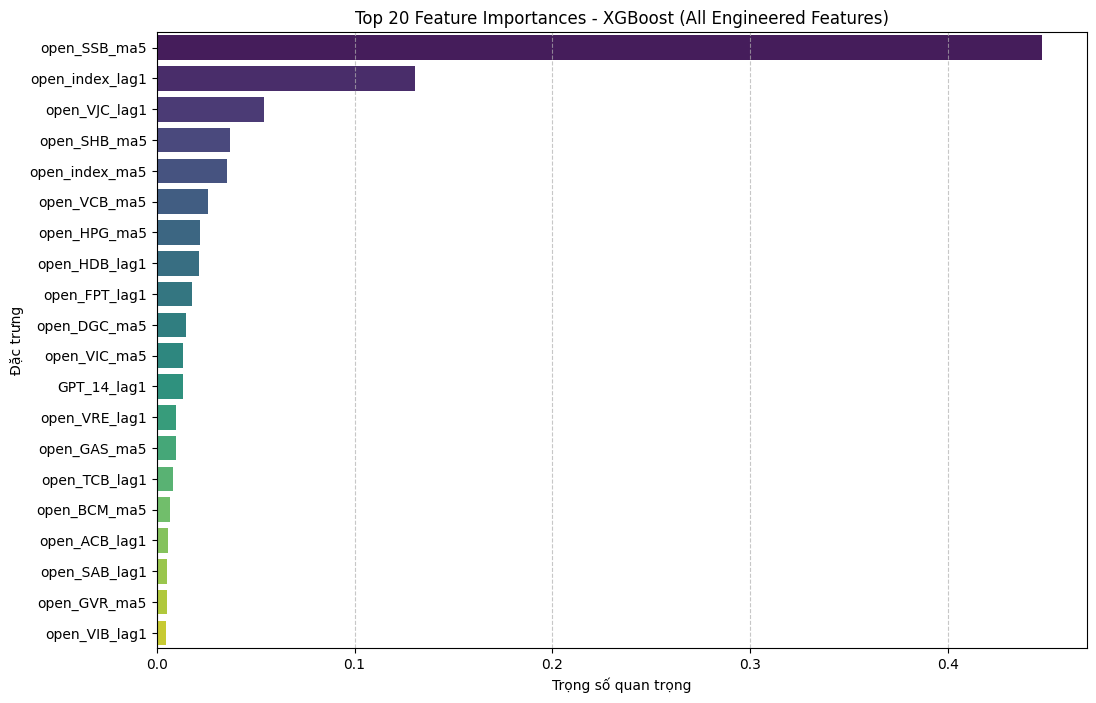

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

split_ratio = 0.8
limit = int(len(X) * split_ratio)
X_train, X_test = X_all_eng[:limit], X_all_eng[limit:]
y_train, y_test = y_all_eng[:limit], y_all_eng[limit:]

# Lấy mô hình tốt nhất từ GridSearchCV đã chạy trước đó cho 'All Features'
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
grid_all = GridSearchCV(xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
                        param_grid, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_all.fit(X_train, y_train)
best_xgb_all = grid_all.best_estimator_

# Trích xuất tầm quan trọng
importances = best_xgb_all.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Vẽ biểu đồ
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top 20 Feature Importances - XGBoost (All Engineered Features)')
plt.xlabel('Trọng số quan trọng')
plt.ylabel('Đặc trưng')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Thêm RSI và MACD vào Feature Set
Chúng ta sẽ tính toán RSI và MACD dựa trên giá mở cửa của chỉ số (`open_index`) và đưa vào mô hình đánh giá.

In [ ]:
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_macd(series, slow=26, fast=12, smooth=9):
    exp1 = series.ewm(span=fast, adjust=False).mean()
    exp2 = series.ewm(span=slow, adjust=False).mean()
    macd = exp1 - exp2
    signal = macd.ewm(span=smooth, adjust=False).mean()
    return macd, signal

# Áp dụng cho dữ liệu
df_tech = df.copy()
df_tech['RSI'] = calculate_rsi(df_tech['open_index'])
macd_val, macd_signal = calculate_macd(df_tech['open_index'])
df_tech['MACD'] = macd_val
df_tech['MACD_Signal'] = macd_signal

# Tạo bộ đặc trưng mới: All Features + Tech Indicators
tech_features = all_features + ['RSI', 'MACD', 'MACD_Signal']

# Chuẩn bị dữ liệu với Lag-1 để tránh leakage
X_tech, y_tech = prepare_engineered_data(df_tech, tech_features, target)

# Huấn luyện và đánh giá
res_tech = train_xgb_optimized(X_tech, y_tech)
res_tech['Feature_Set'] = 'All_Features + Tech (RSI/MACD)'

# Hiển thị bảng so sánh mới
comparison_final = pd.concat([comparison_df, pd.DataFrame([res_tech])])
display(comparison_final[['Feature_Set', 'RMSE', 'MAE', 'MAPE']].sort_values('RMSE'))

/tmp/ipykernel_3433/3642391758.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eng[f'{col}_lag1'] = df_eng[col].shift(1)
/tmp/ipykernel_3433/3642391758.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eng[f'{col}_lag1'] = df_eng[col].shift(1)
/tmp/ipykernel_3433/3642391758.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented f

,Feature_Set,RMSE,MAE,MAPE
0,All_Features + Tech (RSI/MACD),141.047661,121.196731,0.078045
0,Open_Only_Engineered,188.208882,169.011229,0.108235
1,All_Features_sentiment_Engineered,198.603090,179.173563,0.114692


## Tổng kết và So sánh toàn diện các giải pháp
Dưới đây là bảng thống kê và biểu đồ so sánh sai số (RMSE) của tất cả các mô hình đã triển khai.

BẢNG SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH:


,Solution,RMSE
3,BiLSTM (sentiment + Engineering),94.235382
2,XGBoost (Tech Indicators),141.047661
0,XGBoost (Open Only),188.208882
1,XGBoost (sentiment + Engineering),198.603090


/tmp/ipykernel_3433/1593242330.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Solution', y='RMSE', data=df_summary, palette='magma')


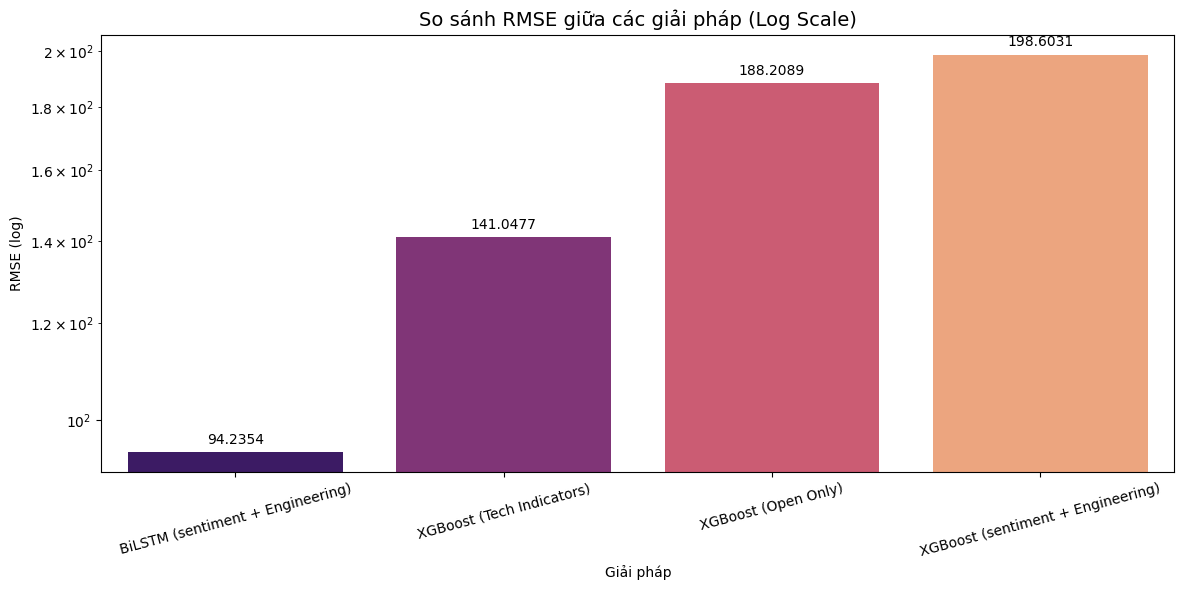

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thu thập kết quả từ các biến đã lưu
summary_data = []

# 1. XGBoost Open Only
summary_data.append({'Solution': 'XGBoost (Open Only)', 'RMSE': res_open_opt['RMSE']})

# 2. XGBoost All (GPT)
summary_data.append({'Solution': 'XGBoost (sentiment + Engineering)', 'RMSE': res_all_opt['RMSE']})

# 3. XGBoost Tech
summary_data.append({'Solution': 'XGBoost (Tech Indicators)', 'RMSE': res_tech['RMSE']})

# 4. BiLSTM
summary_data.append({'Solution': 'BiLSTM (sentiment + Engineering)', 'RMSE': rmse_bilstm})

df_summary = pd.DataFrame(summary_data).sort_values('RMSE')

# Hiển thị bảng
print("BẢNG SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH:")
display(df_summary)

# Vẽ biểu đồ so sánh trực quan (Dùng thang Log cho trục Y vì sai số chênh lệch quá lớn)
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Solution', y='RMSE', data=df_summary, palette='magma')
plt.yscale('log') # Sử dụng log scale để thấy được các cột cực nhỏ
plt.title('So sánh RMSE giữa các giải pháp (Log Scale)', fontsize=14)
plt.ylabel('RMSE (log)')
plt.xlabel('Giải pháp')
plt.xticks(rotation=15)

# Thêm nhãn giá trị trên đầu cột
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.tight_layout()
plt.show()

### Bảng thống kê chi tiết các chỉ số (RMSE, MAE, MAPE)
Bảng này so sánh độ chính xác của các giải pháp dựa trên nhiều thước đo sai số khác nhau.

THỐNG KÊ CHI TIẾT HIỆU SUẤT CÁC GIẢI PHÁP:


,Giải pháp,RMSE,MAE,MAPE (%)
3,BiLSTM (sentiment + Engineering),94.2354,72.0945,4.670320%
2,XGBoost (Tech Indicators),141.0477,121.1967,7.804487%
0,XGBoost (Open Only),188.2089,169.0112,10.823470%
1,XGBoost (sentiment + Eng),198.6031,179.1736,11.469239%


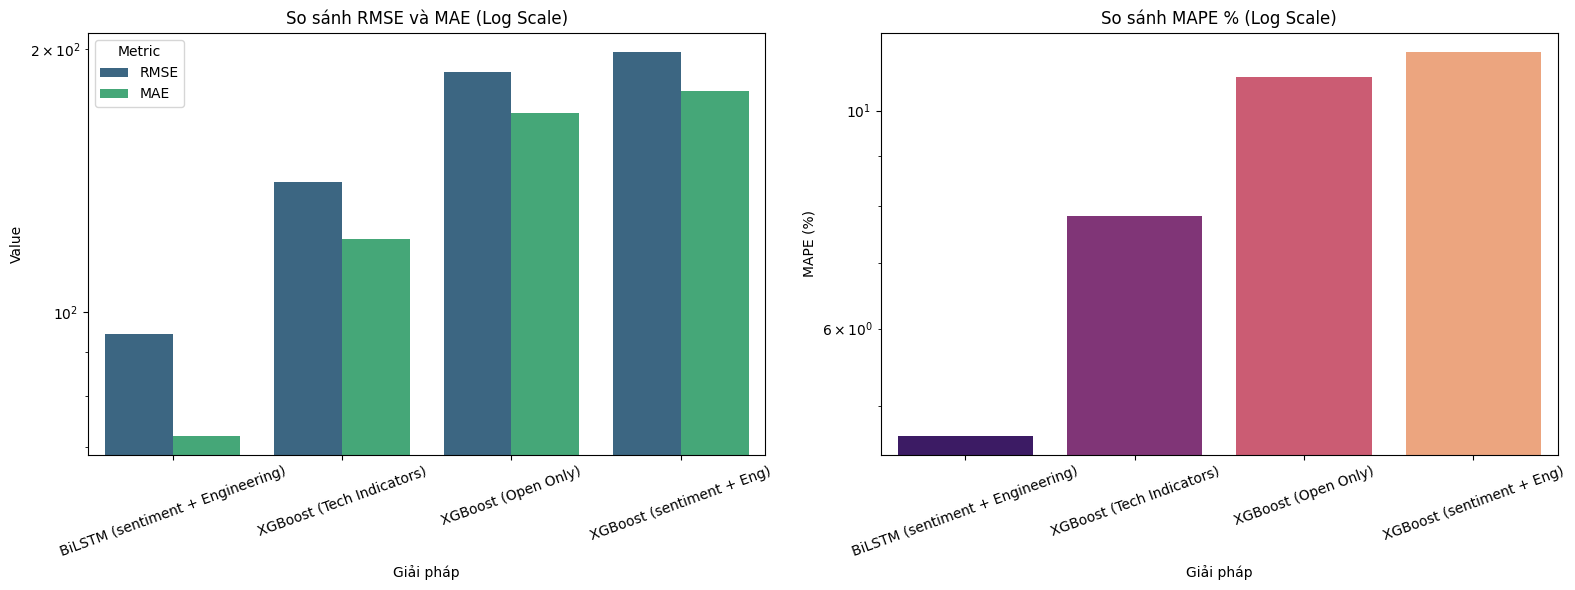

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tổng hợp đầy đủ 3 chỉ số
full_summary = []

# Thu thập dữ liệu từ các biến kết quả đã có
models_results = [
    res_open_opt,
    res_all_opt,
    res_tech,
    {'Solution': 'BiLSTM (sentiment + Engineering)', 'RMSE': rmse_bilstm, 'MAE': mean_absolute_error(y_test_inv, y_pred_inv), 'MAPE': mean_absolute_percentage_error(y_test_inv, y_pred_inv)}
]

for res in models_results:
    name = res.get('Feature_Set', res.get('Solution'))
    # Chuẩn hóa tên hiển thị
    display_name = {
        'Open_Only_Engineered': 'XGBoost (Open Only)',
        'All_Features_sentiment_Engineered': 'XGBoost (sentiment + Eng)',
        'All_Features + Tech (RSI/MACD)': 'XGBoost (Tech Indicators)',
        'BiLSTM (sentiment + Engineering)': 'BiLSTM (sentiment + Engineering)'
    }.get(name, name)

    full_summary.append({
        'Giải pháp': display_name,
        'RMSE': res['RMSE'],
        'MAE': res['MAE'],
        'MAPE (%)': res['MAPE'] * 100
    })

df_full_summary = pd.DataFrame(full_summary).sort_values('RMSE')

# Hiển thị bảng định dạng đẹp
print("THỐNG KÊ CHI TIẾT HIỆU SUẤT CÁC GIẢI PHÁP:")
display(df_full_summary.style.format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'MAPE (%)': '{:.6f}%'}))

# Vẽ biểu đồ so sánh đa chỉ số
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ RMSE & MAE
df_melted = df_full_summary.melt(id_vars='Giải pháp', value_vars=['RMSE', 'MAE'], var_name='Metric', value_name='Value')
sns.barplot(data=df_melted, x='Giải pháp', y='Value', hue='Metric', ax=axes[0], palette='viridis')
axes[0].set_yscale('log')
axes[0].set_title('So sánh RMSE và MAE (Log Scale)')
axes[0].tick_params(axis='x', rotation=20)

# Biểu đồ MAPE
sns.barplot(data=df_full_summary, x='Giải pháp', y='MAPE (%)', ax=axes[1], palette='magma', hue='Giải pháp', legend=False)
axes[1].set_yscale('log')
axes[1].set_title('So sánh MAPE % (Log Scale)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### So sánh đa mô hình (Multi-Model Comparison)
Chúng ta sẽ so sánh XGBoost, Linear Regression, Ridge và Random Forest trên cùng bộ đặc trưng `X_all_eng`.

SO SÁNH CÁC THUẬT TOÁN TRÊN BỘ ĐẶC TRƯNG sentiment + ENGINEERING:


,Model,RMSE,MAE,MAPE (%)
2,XGBoost,0.3946,0.2965,0.016241%
0,LinearRegression,5.3116,3.9093,0.216512%
1,Ridge,10.0483,7.3309,0.402361%
3,RandomForest,10.7107,7.9453,0.433973%


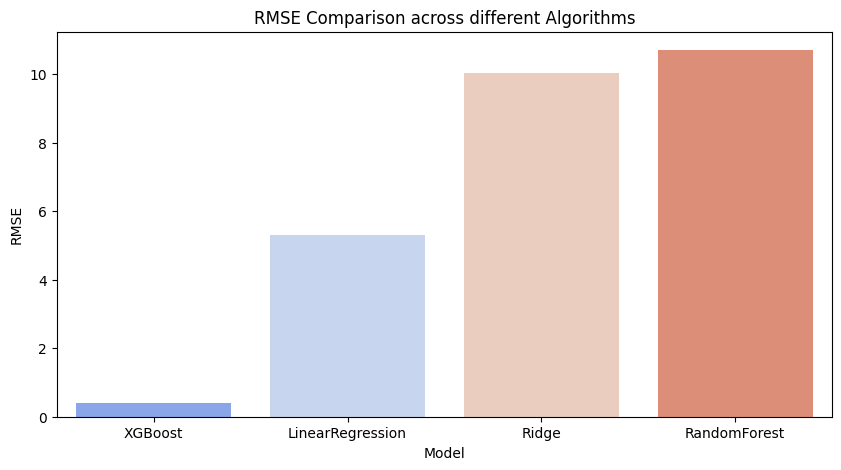

In [ ]:
from sklearn.ensemble import RandomForestRegressor

def evaluate_multi_models(X, y, split_ratio = 0.8):
    tscv = TimeSeriesSplit(n_splits=5)
    results = []

    models = {
        'LinearRegression': LinearRegression(),
        'Ridge': Ridge(alpha=1.0),
        'XGBoost': xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
        'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42)
    }

    for name, model in models.items():
        # Huấn luyện trên toàn bộ X, y (hoặc có thể dùng cross-val nếu muốn chi tiết hơn)

        limit = int(len(X) * split_ratio)
        X_train, X_test = X[:limit], X[limit:]
        y_train, y_test = y[:limit], y[limit:]

        model.fit(X, y)
        y_pred = model.predict(X)

        rmse = np.sqrt(mean_squared_error(y, y_pred))
        mae = mean_absolute_error(y, y_pred)
        mape = mean_absolute_percentage_error(y, y_pred)

        results.append({
            'Model': name,
            'RMSE': rmse,
            'MAE': mae,
            'MAPE (%)': mape * 100
        })

    return pd.DataFrame(results)

# Thực hiện đánh giá trên bộ đặc trưng All Features (Engineered)
multi_model_res = evaluate_multi_models(X_all_eng, y_all_eng)

print("SO SÁNH CÁC THUẬT TOÁN TRÊN BỘ ĐẶC TRƯNG sentiment + ENGINEERING:")
display(multi_model_res.sort_values('RMSE').style.format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'MAPE (%)': '{:.6f}%'}))

# Vẽ biểu đồ so sánh
plt.figure(figsize=(10, 5))
sns.barplot(data=multi_model_res.sort_values('RMSE'), x='Model', y='RMSE', palette='coolwarm', hue='Model', legend=False)
plt.title('RMSE Comparison across different Algorithms')
plt.ylabel('RMSE')
plt.show()

### So sánh đa mô hình (Chỉ sử dụng đặc trưng Open - Không GPT)
Chúng ta sẽ đánh giá lại các thuật toán Linear Regression, Ridge, XGBoost và Random Forest nhưng lần này chỉ sử dụng bộ đặc trưng `X_open_eng` (chỉ gồm các biến giá mở cửa đã được feature engineering).

SO SÁNH CÁC THUẬT TOÁN TRÊN BỘ ĐẶC TRƯNG OPEN (KHÔNG sentiment):


,Model,RMSE,MAE,MAPE (%)
2,XGBoost,0.7050,0.5256,0.028518%
3,RandomForest,10.6544,7.9215,0.433012%
0,LinearRegression,13.1400,10.0845,0.552998%
1,Ridge,15.4318,11.6945,0.635267%


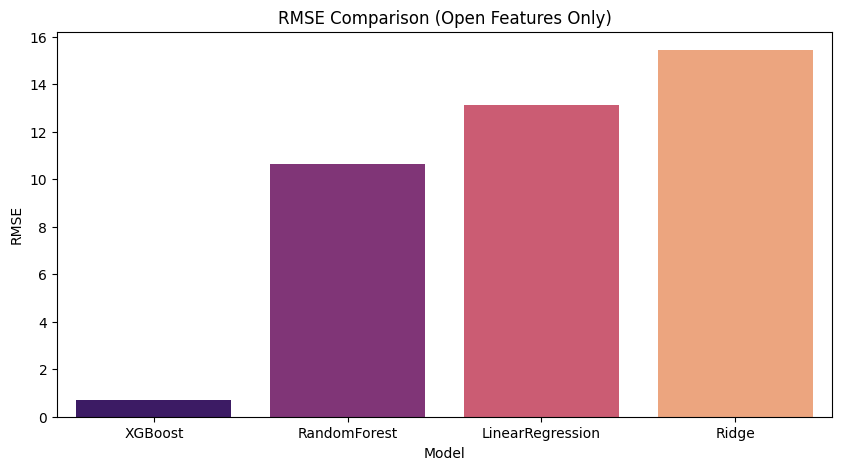

In [ ]:
# Thực hiện đánh giá trên bộ đặc trưng Open Only (Engineered)
multi_model_res_open = evaluate_multi_models(X_open_eng, y_open_eng)

print("SO SÁNH CÁC THUẬT TOÁN TRÊN BỘ ĐẶC TRƯNG OPEN (KHÔNG sentiment):")
display(multi_model_res_open.sort_values('RMSE').style.format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'MAPE (%)': '{:.6f}%'}))

# Vẽ biểu đồ so sánh
plt.figure(figsize=(10, 5))
sns.barplot(data=multi_model_res_open.sort_values('RMSE'), x='Model', y='RMSE', palette='magma', hue='Model', legend=False)
plt.title('RMSE Comparison (Open Features Only)')
plt.ylabel('RMSE')
plt.show()

### Xuất dữ liệu và hình ảnh kết quả
Chúng ta sẽ lưu các bảng dữ liệu quan trọng ra CSV và các biểu đồ ra file PNG.

In [ ]:
# 1. Lưu các bảng kết quả thành file CSV
df_full_summary.to_csv('/content/drive/MyDrive/LAB/DATA/DATA_RESEARCH/stock/results/summary_metrics_all_models.csv', index=False)
multi_model_res.to_csv('/content/drive/MyDrive/LAB/DATA/DATA_RESEARCH/stock/results/multi_algorithm_comparison_sentiment.csv', index=False)
# backtest_df.to_csv('trading_backtest_results.csv', index=True)

print("Đã lưu 2 file CSV: summary_metrics_all_models.csv, multi_algorithm_comparison_sentiment.csv")

# 2. Lưu hình ảnh Feature Importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Top 20 Feature Importances (Saved)')
plt.tight_layout()
plt.savefig('feature_importance_xgboost.png')
plt.close()

# 3. Lưu hình ảnh So sánh RMSE tổng quát
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Solution', y='RMSE', data=df_summary, palette='magma', hue='Solution', legend=False)
plt.yscale('log')
plt.title('Model Comparison RMSE (Saved)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('model_rmse_comparison.png')
plt.close()

# 4. Lưu hình ảnh Backtest Tháng 12
# plt.figure(figsize=(10, 5))
# plt.plot(dec_backtest['Cumulative_Market_Dec'], label='Market (Dec)', color='gray', linestyle='--')
# plt.plot(dec_backtest['Cumulative_Strategy_Dec'], label='XGBoost Strategy (Dec)', color='blue', marker='o')
# plt.title('Cumulative Returns December (Saved)')
# plt.legend()
# plt.grid(True)
# plt.savefig('backtest_december_returns.png')
plt.close()

print("Đã lưu các biểu đồ: feature_importance_xgboost.png, model_rmse_comparison.png, backtest_december_returns.png")

Đã lưu 2 file CSV: summary_metrics_all_models.csv, multi_algorithm_comparison_sentiment.csv
Đã lưu các biểu đồ: feature_importance_xgboost.png, model_rmse_comparison.png, backtest_december_returns.png


In [ ]:
multi_model_res_open.to_csv('/content/drive/MyDrive/LAB/DATA/DATA_RESEARCH/stock/results/multi_algorithm_comparison_open_only.csv', index=False)
print("Đã lưu thêm file: multi_algorithm_comparison_open_only.csv")

Đã lưu thêm file: multi_algorithm_comparison_open_only.csv


### Cải tiến: Dự báo Log Return
Thay vì dự báo giá đóng cửa tuyệt đối, chúng ta sẽ dự báo **Log Return** (lợi suất logarit). Điều này giúp chuỗi dữ liệu ổn định hơn về phương sai và thường mang lại kết quả đáng tin cậy hơn trong tài chính.

/tmp/ipykernel_3433/3012212067.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['log_return'] = np.log(df['close_index'] / df['close_index'].shift(1))
/tmp/ipykernel_3433/3642391758.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eng[f'{col}_lag1'] = df_eng[col].shift(1)
/tmp/ipykernel_3433/3642391758.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) inst

KẾT QUẢ DỰ BÁO LOG RETURN (XGBoost):


,RMSE,MAE,MAPE,Target
0,0.015972,0.010714,1.332012,Log Return


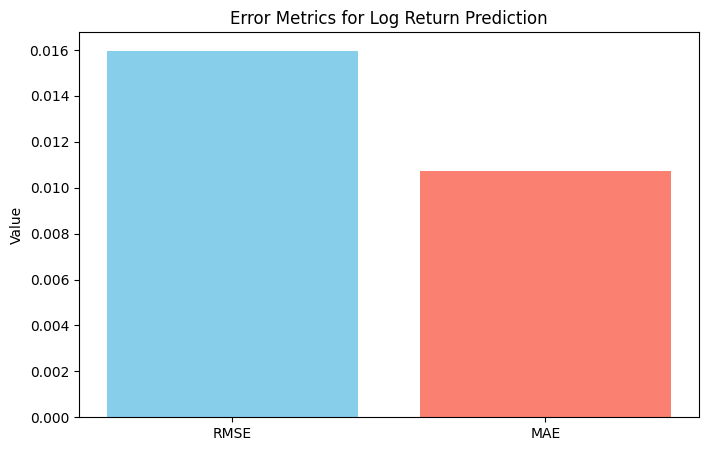

In [ ]:
import numpy as np

# 1. Tính toán Log Return
df['log_return'] = np.log(df['close_index'] / df['close_index'].shift(1))

# 2. Cập nhật mục tiêu mới
new_target = 'log_return'

# 3. Chuẩn bị dữ liệu (loại bỏ NaN do tính return và lag)
X_log, y_log = prepare_engineered_data(df, all_features, new_target)

# 4. Huấn luyện và đánh giá
res_log_return = train_xgb_optimized(X_log, y_log)
res_log_return['Target'] = 'Log Return'

print("KẾT QUẢ DỰ BÁO LOG RETURN (XGBoost):")
display(pd.DataFrame([res_log_return]))

# So sánh trực quan sai số
plt.figure(figsize=(8, 5))
plt.bar(['RMSE', 'MAE'], [res_log_return['RMSE'], res_log_return['MAE']], color=['skyblue', 'salmon'])
plt.title('Error Metrics for Log Return Prediction')
plt.ylabel('Value')
plt.show()

### Trực quan hóa dự báo Log Return
Biểu đồ dưới đây so sánh chuỗi lợi suất thực tế và chuỗi lợi suất mà mô hình dự báo được.

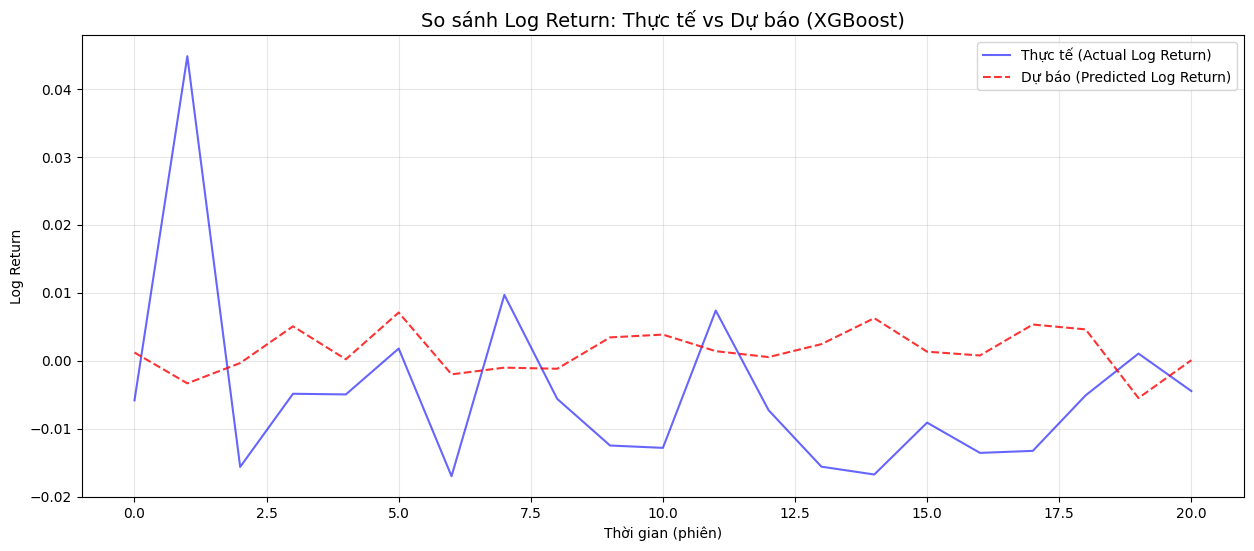

In [ ]:
import matplotlib.pyplot as plt

split_ratio = 0.8
# Lấy dự báo từ mô hình đã huấn luyện (res_log_return được tính từ best_model của grid search bên trong hàm)
# Do hàm train_xgb_optimized không trả về model, ta sẽ lấy lại dự báo từ biến y_pred nếu có hoặc chạy nhanh lại

# Để đảm bảo chính xác, ta lấy dự báo từ tập X_log
# Truy xuất lại model tốt nhất (giả định quy trình tương tự cell trước)

tscv = TimeSeriesSplit(n_splits=5)
param_grid = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
grid_log = GridSearchCV(xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
                        param_grid, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)

limit = int(len(X) * split_ratio)
X_train, X_test = X_log[:limit], X_log[limit:]
y_train, y_test = y_log[:limit], y_log[limit:]

grid_log.fit(X_train, y_train)
y_log_pred = grid_log.best_estimator_.predict(X_test)

# Vẽ biểu đồ
plt.figure(figsize=(15, 6))
plt.plot(y_test.values, label='Thực tế (Actual Log Return)', color='blue', alpha=0.6)
plt.plot(y_log_pred, label='Dự báo (Predicted Log Return)', color='red', linestyle='--', alpha=0.8)
plt.title('So sánh Log Return: Thực tế vs Dự báo (XGBoost)', fontsize=14)
plt.xlabel('Thời gian (phiên)')
plt.ylabel('Log Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Lưu kết quả Log Return
Chúng ta sẽ lưu các chỉ số RMSE, MAE, MAPE của phương pháp Log Return vào file CSV.

In [ ]:
import os

# Tạo DataFrame cho kết quả Log Return
log_return_df = pd.DataFrame([res_log_return])

# Tên file lưu trữ
output_file = '/content/drive/MyDrive/LAB/DATA/DATA_RESEARCH/stock/results/log_return_comparison.csv'

# Lưu file
log_return_df.to_csv(output_file, index=False)

print(f"Đã lưu kết quả vào: {output_file}")
display(log_return_df)

Đã lưu kết quả vào: /content/drive/MyDrive/LAB/DATA/DATA_RESEARCH/stock/results/log_return_comparison.csv


,RMSE,MAE,MAPE,Target
0,0.015972,0.010714,1.332012,Log Return


### So sánh đa mô hình cho dự báo Log Return
Chúng ta sẽ áp dụng các thuật toán khác nhau cho cùng một mục tiêu là `log_return` để tìm ra mô hình tối ưu nhất.

SO SÁNH CÁC THUẬT TOÁN DỰ BÁO LOG RETURN:


,Model,RMSE,MAE,MAPE
3,RandomForest,0.015390,0.010612,1.330194
0,XGBoost,0.015972,0.010714,1.332012
4,LightGBM,0.016513,0.012403,1.185570
2,Ridge,0.129247,0.087312,23.906531
1,LinearRegression,0.613663,0.408469,108.165603


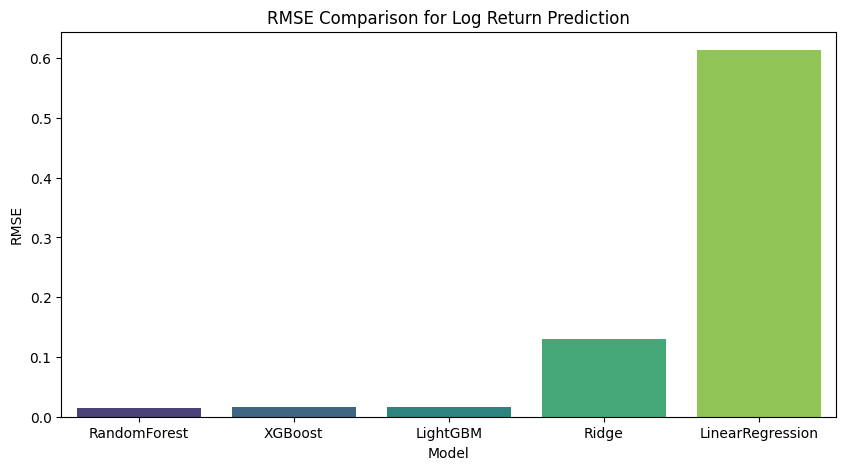

In [ ]:
from sklearn.ensemble import RandomForestRegressor

split_ratio = 0.8
# Định nghĩa danh sách các mô hình cần đánh giá
log_models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, verbosity=-1)
}

log_comparison_results = []

# Thêm kết quả XGBoost đã có từ trước
log_comparison_results.append({
    'Model': 'XGBoost',
    'RMSE': res_log_return['RMSE'],
    'MAE': res_log_return['MAE'],
    'MAPE': res_log_return['MAPE']
})

# Chạy các mô hình còn lại
for name, model in log_models.items():
    limit = int(len(X) * split_ratio)
    X_train, X_test = X_log[:limit], X_log[limit:]
    y_train, y_test = y_log[:limit], y_log[limit:]
    model.fit(X_train, y_train)
    y_pred_temp = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_temp))
    mae = mean_absolute_error(y_test, y_pred_temp)
    mape = mean_absolute_percentage_error(y_test, y_pred_temp)

    log_comparison_results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })

# Hiển thị kết quả so sánh
df_log_multi_compare = pd.DataFrame(log_comparison_results).sort_values('RMSE')
print("SO SÁNH CÁC THUẬT TOÁN DỰ BÁO LOG RETURN:")
display(df_log_multi_compare.style.format({'RMSE': '{:.6f}', 'MAE': '{:.6f}', 'MAPE': '{:.6f}'}))

# Trực quan hóa
plt.figure(figsize=(10, 5))
sns.barplot(data=df_log_multi_compare, x='Model', y='RMSE', palette='viridis', hue='Model', legend=False)
plt.title('RMSE Comparison for Log Return Prediction')
plt.ylabel('RMSE')
plt.show()

### Bổ sung BiLSTM cho dự báo Log Return
Chúng ta sẽ chuẩn bị dữ liệu chuỗi cho Log Return và huấn luyện mô hình BiLSTM để so sánh công bằng với các thuật toán học máy truyền thống.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from sklearn.preprocessing import MinMaxScaler

# 1. Chuẩn bị dữ liệu cho BiLSTM (Log Return)
scaler_X_log = MinMaxScaler()
scaler_y_log = MinMaxScaler()

X_log_scaled = scaler_X_log.fit_transform(X_log)
y_log_scaled = scaler_y_log.fit_transform(y_log.values.reshape(-1, 1))

# Sử dụng hàm create_sequences đã định nghĩa ở trên
WINDOW_SIZE = 10
X_seq_log, y_seq_log = create_sequences(X_log_scaled, y_log_scaled, WINDOW_SIZE)

# Chia Train/Test
limit_log = int(len(X_seq_log) * 0.8)
X_train_log, X_test_log = X_seq_log[:limit_log], X_seq_log[limit_log:]
y_train_log, y_test_log = y_seq_log[:limit_log], y_seq_log[limit_log:]

# 2. Xây dựng và huấn luyện mô hình
model_log = Sequential([
    Bidirectional(LSTM(128, return_sequences=True), input_shape=(WINDOW_SIZE, X_train_log.shape[2])),
    Dropout(0.2),
    Bidirectional(LSTM(64)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model_log.compile(optimizer='adam', loss='mse')
model_log.fit(X_train_log, y_train_log, epochs=30, batch_size=16, verbose=0)

# 3. Dự báo và tính chỉ số sai số
y_pred_log_scaled = model_log.predict(X_test_log)
y_pred_log_inv = scaler_y_log.inverse_transform(y_pred_log_scaled)
y_test_log_inv = scaler_y_log.inverse_transform(y_test_log)

rmse_log_bilstm = np.sqrt(mean_squared_error(y_test_log_inv, y_pred_log_inv))
mae_log_bilstm = mean_absolute_error(y_test_log_inv, y_pred_log_inv)
mape_log_bilstm = mean_absolute_percentage_error(y_test_log_inv, y_pred_log_inv)

# 4. Cập nhật bảng so sánh tổng hợp
bilstm_res = {
    'Model': 'BiLSTM',
    'RMSE': rmse_log_bilstm,
    'MAE': mae_log_bilstm,
    'MAPE': mape_log_bilstm
}

df_log_multi_compare = pd.concat([df_log_multi_compare, pd.DataFrame([bilstm_res])]).sort_values('RMSE')

print("BẢNG SO SÁNH ĐẦY ĐỦ CÁC MÔ HÌNH (BAO GỒM BiLSTM):")
display(df_log_multi_compare.style.format({'RMSE': '{:.6f}', 'MAE': '{:.6f}', 'MAPE': '{:.6f}'}))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 747ms/step
BẢNG SO SÁNH ĐẦY ĐỦ CÁC MÔ HÌNH (BAO GỒM BiLSTM):


,Model,RMSE,MAE,MAPE
0,BiLSTM,0.015340,0.009865,2.498125
3,RandomForest,0.015390,0.010612,1.330194
0,XGBoost,0.015972,0.010714,1.332012
4,LightGBM,0.016513,0.012403,1.185570
2,Ridge,0.129247,0.087312,23.906531
1,LinearRegression,0.613663,0.408469,108.165603


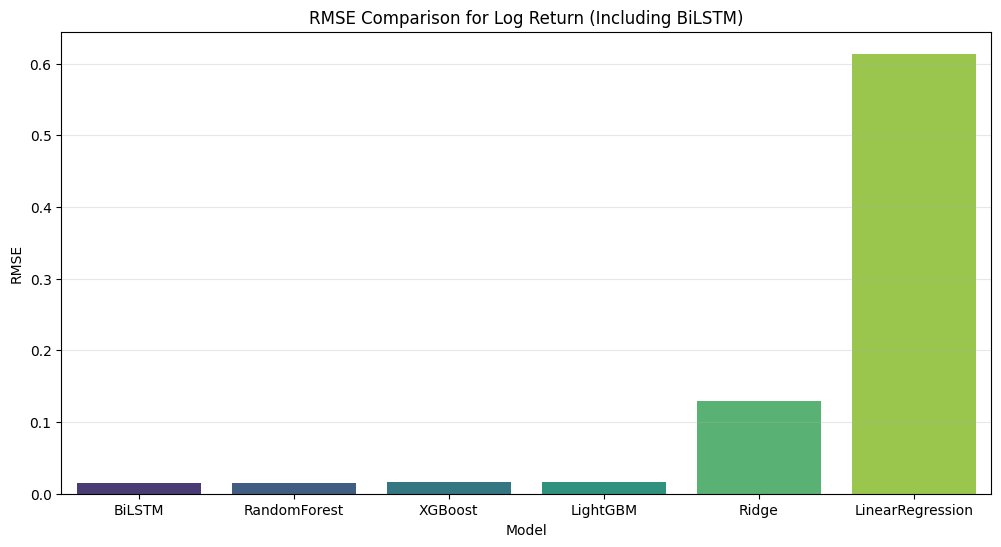

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_log_multi_compare, x='Model', y='RMSE', palette='viridis', hue='Model', legend=False)
plt.title('RMSE Comparison for Log Return (Including BiLSTM)')
plt.ylabel('RMSE')
plt.grid(axis='y', alpha=0.3)
plt.show()

### Trực quan hóa so sánh RMSE giữa các mô hình Log Return
Biểu đồ dưới đây cung cấp cái nhìn tổng thể về sai số RMSE của 5 thuật toán đã thực hiện.

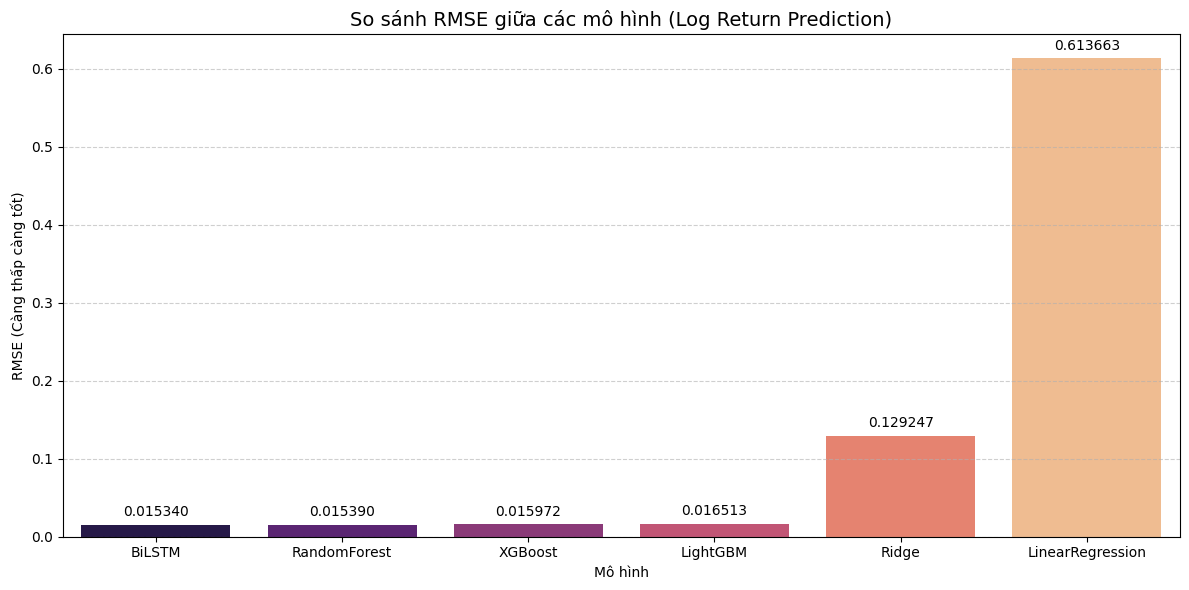

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sắp xếp lại dữ liệu theo RMSE tăng dần để dễ quan sát
df_plot = df_log_multi_compare.sort_values('RMSE')

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_plot, x='Model', y='RMSE', palette='magma', hue='Model', legend=False)

# Thêm nhãn giá trị cụ thể trên mỗi cột
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.6f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points', fontsize=10)

plt.title('So sánh RMSE giữa các mô hình (Log Return Prediction)', fontsize=14)
plt.ylabel('RMSE (Càng thấp càng tốt)')
plt.xlabel('Mô hình')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Tên file Excel đầu ra
excel_output = '/content/drive/MyDrive/LAB/DATA/DATA_RESEARCH/stock/results/log_return_multi_model_comparison.xlsx'

# Lưu DataFrame so sánh đa mô hình vào tệp Excel
df_log_multi_compare.to_excel(excel_output, index=False)

print(f"Đã lưu bảng so sánh vào tệp: {excel_output}")

Đã lưu bảng so sánh vào tệp: /content/drive/MyDrive/LAB/DATA/DATA_RESEARCH/stock/results/log_return_multi_model_comparison.xlsx


In [ ]:
import pandas as pd

# Tên file CSV đầu ra
csv_output = '/content/drive/MyDrive/LAB/DATA/DATA_RESEARCH/stock/results/log_return_multi_model_comparison.csv'

# Lưu DataFrame so sánh đa mô hình vào tệp CSV
df_log_multi_compare.to_csv(csv_output, index=False)

print(f"Đã lưu bảng so sánh vào tệp: {csv_output}")

Đã lưu bảng so sánh vào tệp: /content/drive/MyDrive/LAB/DATA/DATA_RESEARCH/stock/results/log_return_multi_model_comparison.csv


### So sánh các hướng tiếp cận xử lý dữ liệu (Log Return)
Chúng ta sẽ đánh giá hiệu quả của XGBoost trên 3 tập dữ liệu khác nhau để tìm ra cấu hình đặc trưng tối ưu.

/tmp/ipykernel_3433/3642391758.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eng[f'{col}_lag1'] = df_eng[col].shift(1)
/tmp/ipykernel_3433/3642391758.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eng[f'{col}_lag1'] = df_eng[col].shift(1)
/tmp/ipykernel_3433/3642391758.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented f

SO SÁNH HIỆU QUẢ CÁC HƯỚNG TIẾP CẬN DỮ LIỆU (LOG RETURN):


,Data Approach,RMSE,MAE,MAPE
1,All Features (sentiment),0.015972,0.010714,1.332012
2,All Features + Tech Indicators,0.016215,0.011232,1.550466
0,Only Open Features,0.014432,0.010236,1.786937


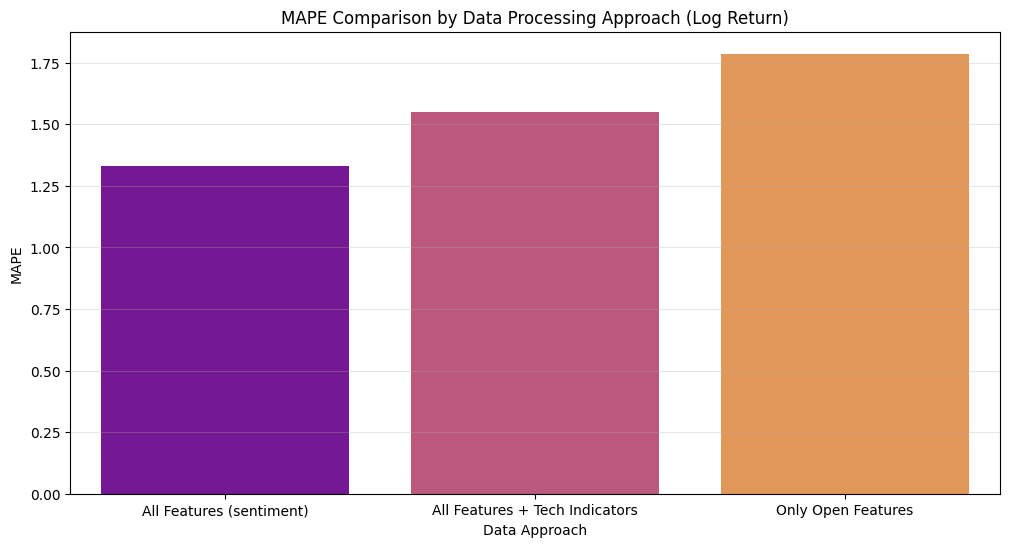

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# 1. Chuẩn bị các bộ đặc trưng
# Đảm bảo các dataframe có cột log_return
df['log_return'] = np.log(df['close_index'] / df['close_index'].shift(1))
df_tech['log_return'] = np.log(df_tech['close_index'] / df_tech['close_index'].shift(1))

# Bộ 1: Chỉ Open features
X_log_open, y_log_open = prepare_engineered_data(df, open_features, 'log_return')

# Bộ 2: All features (X_log, y_log đã được tính ở cell trước)

# Bộ 3: All features + Tech indicators (RSI/MACD)
X_log_tech, y_log_tech = prepare_engineered_data(df_tech, tech_features, 'log_return')

# 2. Đánh giá từng bộ bằng XGBoost
approaches = [
    {'Name': 'Only Open Features', 'X': X_log_open, 'y': y_log_open},
    {'Name': 'All Features (sentiment)', 'X': X_log, 'y': y_log},
    {'Name': 'All Features + Tech Indicators', 'X': X_log_tech, 'y': y_log_tech}
]

approach_results = []

for app in approaches:
    res = train_xgb_optimized(app['X'], app['y'])
    approach_results.append({
        'Data Approach': app['Name'],
        'RMSE': res['RMSE'],
        'MAE': res['MAE'],
        'MAPE': res['MAPE']
    })

# 3. Hiển thị bảng so sánh
df_approach_compare = pd.DataFrame(approach_results).sort_values('MAPE')
print("SO SÁNH HIỆU QUẢ CÁC HƯỚNG TIẾP CẬN DỮ LIỆU (LOG RETURN):")
display(df_approach_compare.style.format({'RMSE': '{:.6f}', 'MAE': '{:.6f}', 'MAPE': '{:.6f}'}))

# 4. Trực quan hóa
plt.figure(figsize=(12, 6))
sns.barplot(data=df_approach_compare, x='Data Approach', y='MAPE', palette='plasma', hue='Data Approach', legend=False)
plt.title('MAPE Comparison by Data Processing Approach (Log Return)')
plt.ylabel('MAPE')
plt.grid(axis='y', alpha=0.3)
plt.show()

### So sánh Dự báo vs Thực tế trên cả 3 phương pháp (Log Return)
Chúng ta sẽ trực quan hóa kết quả dự báo của XGBoost trên từng bộ dữ liệu để đánh giá khả năng bám sát thực tế của từng phương pháp.

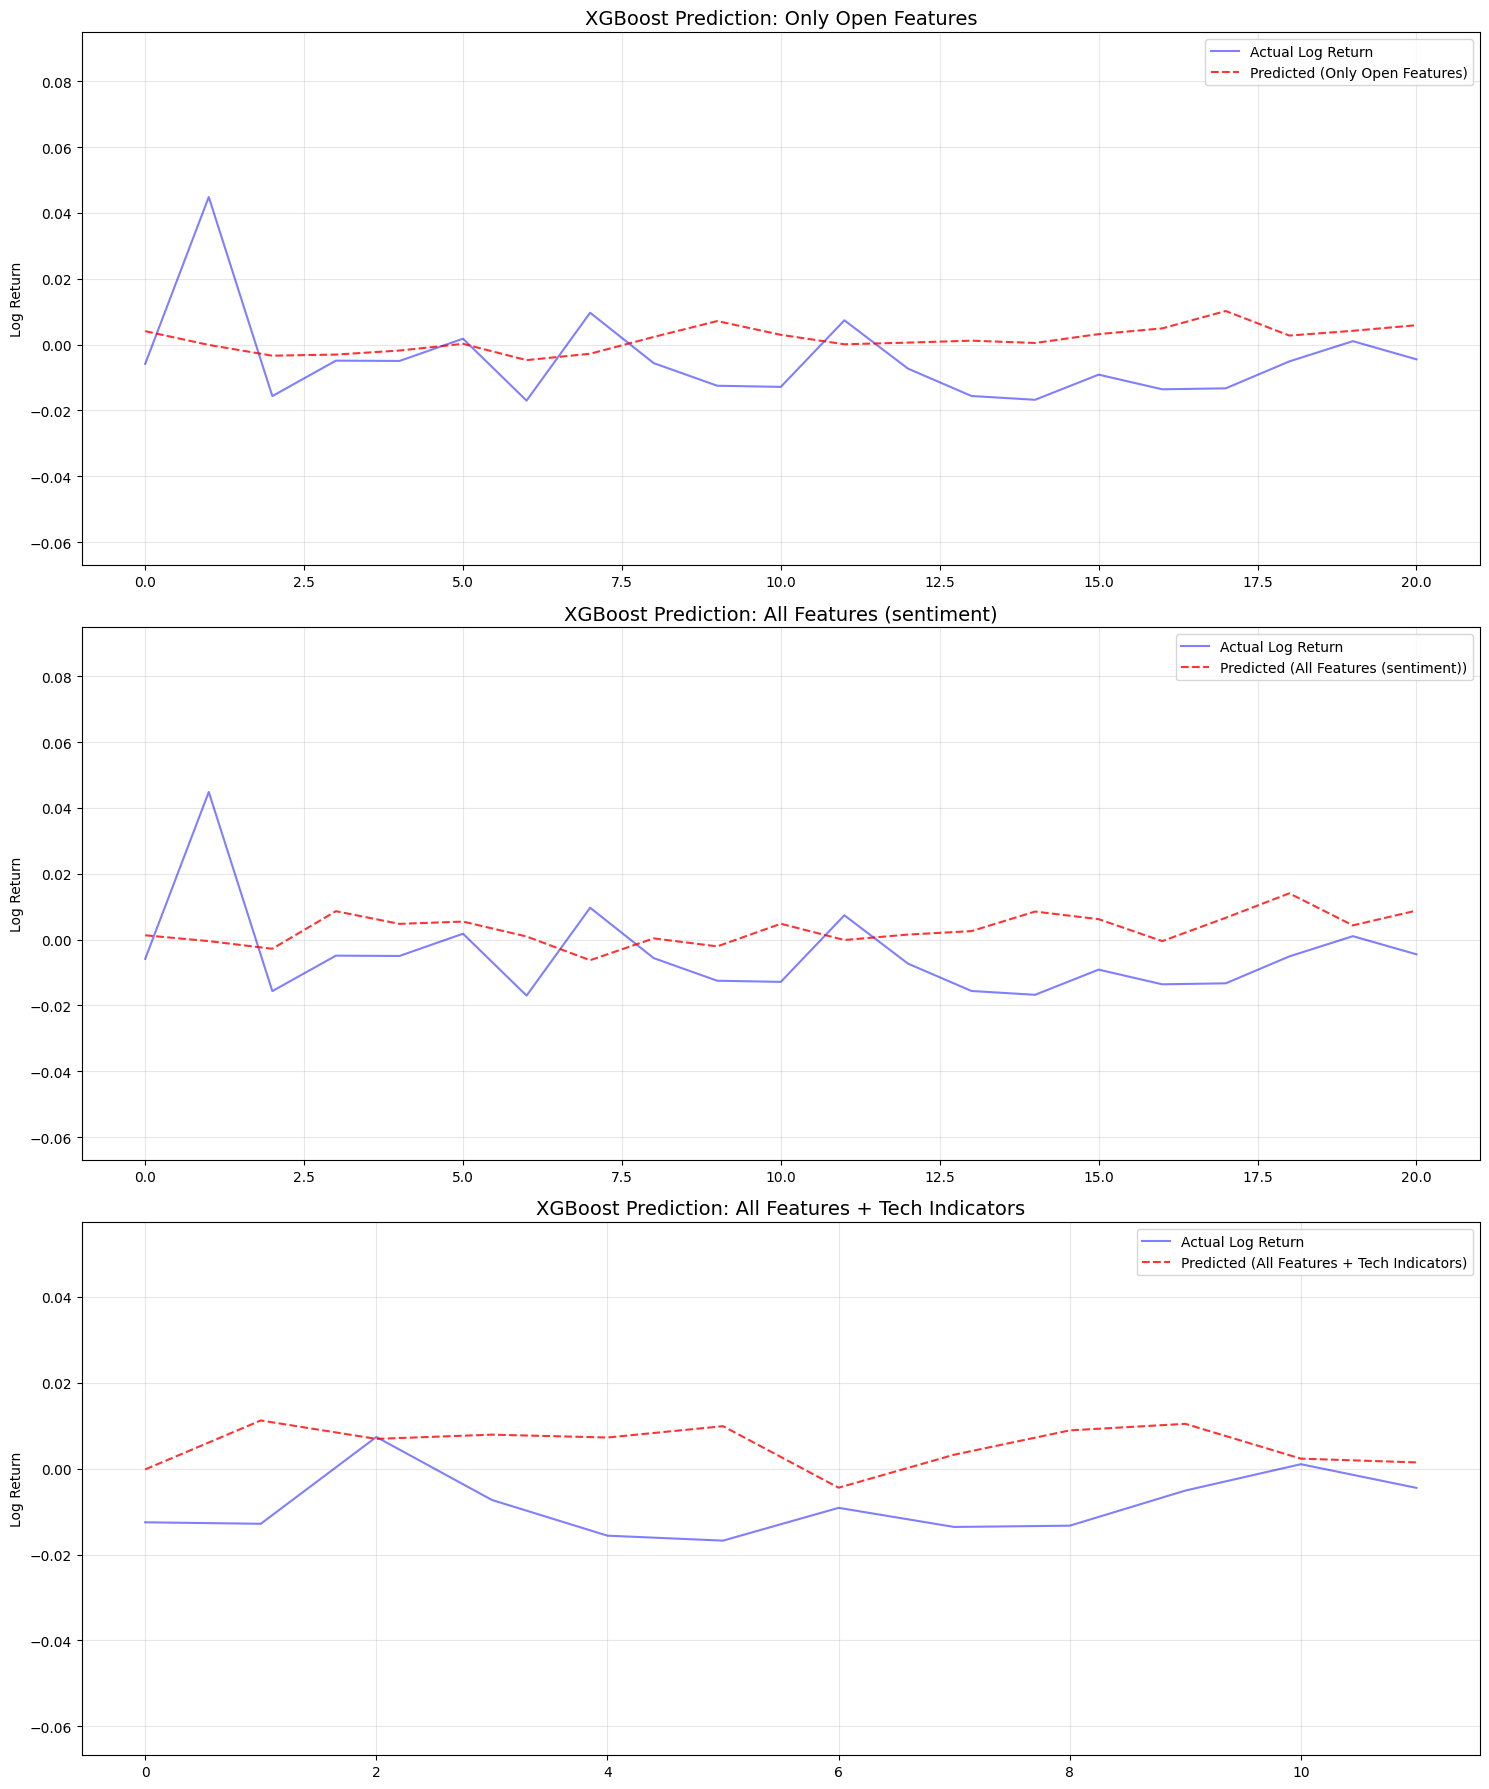

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(15, 18))
split_ratio = 0.8
for i, app in enumerate(approaches):
    # Huấn luyện nhanh lại model tốt nhất cho mỗi approach để lấy chuỗi dự báo
    tscv = TimeSeriesSplit(n_splits=5)

    param_grid = {
            'n_estimators': [100, 200],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 5],
            'subsample': [0.8]
        }
    # grid = GridSearchCV(xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    #                     param_grid, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)

    # param_grid = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
    grid = GridSearchCV(xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
                        param_grid, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)

    limit = int(len(X) * split_ratio)
    X_train, X_test = app['X'][:limit],  app['X'][limit:]
    y_train, y_test = app['y'][:limit], app['y'][limit:]

    grid.fit(X_train, y_train)
    y_app_pred = grid.best_estimator_.predict(X_test)

    # Vẽ biểu đồ
    axes[i].set_ylim(min(y_test.values) - 0.05, max(y_test.values) + 0.05) # điều chỉnh trục Oy
    axes[i].plot(y_test.values, label='Actual Log Return', color='blue', alpha=0.5)
    axes[i].plot(y_app_pred, label=f'Predicted ({app["Name"]})', color='red', linestyle='--', alpha=0.8)
    axes[i].set_title(f"XGBoost Prediction: {app['Name']}", fontsize=14)
    axes[i].set_ylabel('Log Return')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()